Data Loaded:
   Data Point Melting Point (C)  Young Modulus (GPa)  Tensile Strength (MPa)  \
0          84               260                  3.6                      70   
1          54               130                  1.0                      25   
2          71               265                  4.5                      90   
3          46               168                  2.6                      46   
4          45               162                  2.2                      42   

  Notes Reference  
0   PET       [1]  
1   PET       [4]  
2   PET       [6]  
3    PP       [7]  
4    PP      [11]  

Class distribution BEFORE augmentation:
UnifiedLabel
PET    50
PP     50
Name: count, dtype: int64

Class distribution AFTER augmentation:
PET    150
PP     150
Name: count, dtype: int64

Using stratify=labels...

SVM Results:
  Accuracy:  98.89%
  Precision: 0.99
  Recall:    0.99
  F1-Score:  0.99

Decision Tree Results:
  Accuracy:  97.78%
  Precision: 0.98
  Recall:    0.98
  F1

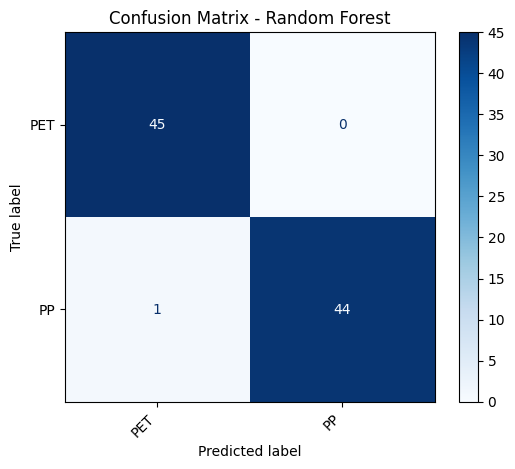

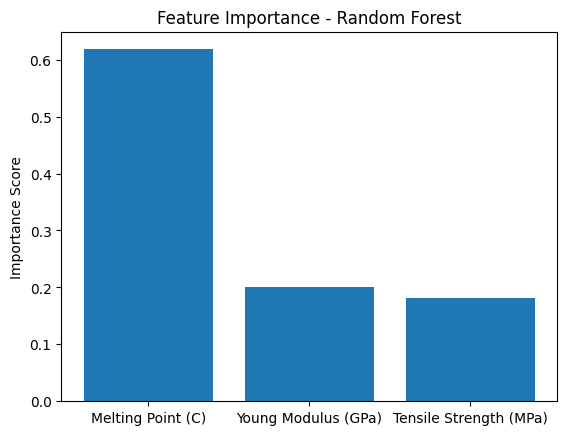

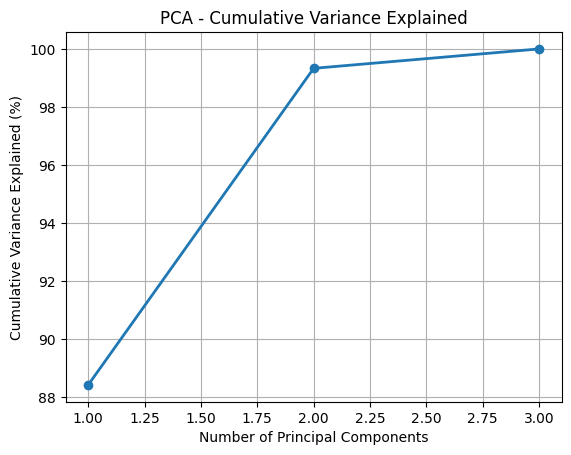

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 203ms/step - accuracy: 0.4238 - loss: 0.6974 - val_accuracy: 0.4762 - val_loss: 0.6923
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.5818 - loss: 0.6891 - val_accuracy: 0.4286 - val_loss: 0.6896
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.5831 - loss: 0.6837 - val_accuracy: 0.4286 - val_loss: 0.6879
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.5336 - loss: 0.6803 - val_accuracy: 0.4048 - val_loss: 0.6856
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.4896 - loss: 0.6748 - val_accuracy: 0.4286 - val_loss: 0.6834
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.5200 - loss: 0.6705 - val_accuracy: 0.4286 - val_loss: 0.6803
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5258 - loss: 0.6666 - val_accuracy: 0.4286 - val_loss: 0.6763
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5637 - loss: 0.6565 - val_accuracy: 0.4286 - val_loss: 0.672

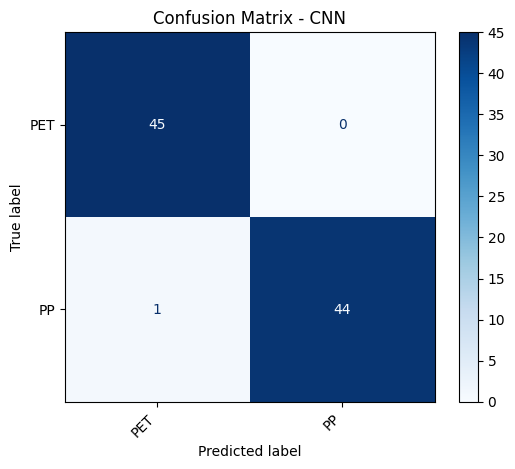

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_recall_fscore_support, ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, InputLayer

# ------------------------------------------------------------------
# 1. HELPER FUNCTIONS
# ------------------------------------------------------------------

def parse_melting_point(value):
    """
    Handle dual melting points like '260/132' by splitting and averaging.
    If there is no slash, just convert to float.
    """
    if isinstance(value, str) and '/' in value:
        parts = value.split('/')
        try:
            floats = [float(x) for x in parts]
            return sum(floats) / len(floats)
        except:
            return np.nan
    else:
        try:
            return float(value)
        except:
            return np.nan

def unify_label(note):
    """
    Convert anything that contains 'pp' to 'PP',
    anything that contains 'pet' to 'PET'.
    Otherwise, return NaN (row will be dropped).
    """
    note_lower = str(note).lower()
    if 'pp' in note_lower:
        return 'PP'
    elif 'pet' in note_lower:
        return 'PET'
    else:
        return np.nan

def augment_numeric_data(X, y, num_copies=1, noise_factor=0.02, random_state=None):
    """
    X: 2D NumPy array or DataFrame of features
    y: 1D array or Series of labels
    num_copies: how many augmented copies to generate per row
    noise_factor: fraction of feature scale used for noise
    random_state: optional integer seed for reproducibility

    Returns: (X_total, y_total), which is the original data plus augmented copies
    """
    if random_state is not None:
        np.random.seed(random_state)

    X_array = np.array(X)
    y_array = np.array(y)

    # Approximate scale of each feature (max-min or standard deviation)
    feature_scales = X_array.max(axis=0) - X_array.min(axis=0)
    feature_scales[feature_scales == 0] = 1e-9  # avoid division by zero

    X_aug_list = []
    y_aug_list = []

    for i in range(len(X_array)):
        original_row = X_array[i]
        label = y_array[i]

        for _ in range(num_copies):
            noise = np.random.normal(
                loc=0.0,
                scale=noise_factor * feature_scales
            )
            new_row = original_row + noise
            X_aug_list.append(new_row)
            y_aug_list.append(label)

    X_aug = np.vstack(X_aug_list)
    y_aug = np.array(y_aug_list)

    # Combine augmented data with original data
    X_total = np.vstack([X_array, X_aug])
    y_total = np.concatenate([y_array, y_aug])

    return X_total, y_total

# ------------------------------------------------------------------
# 2. LOAD & PREPROCESS DATA
# ------------------------------------------------------------------

data = pd.read_csv('PP_random.csv')
print("Data Loaded:")
print(data.head())

# Unify labels to strictly 'PP' or 'PET'
data['UnifiedLabel'] = data['Notes'].apply(unify_label)

# Parse melting point (e.g. '260/132')
data['Melting Point (C)'] = data['Melting Point (C)'].apply(parse_melting_point)

# Drop rows where UnifiedLabel or features are NaN
data.dropna(subset=['Melting Point (C)', 'UnifiedLabel'], inplace=True)

# Final label series
labels = data['UnifiedLabel'].astype('category')

# Feature columns
feature_cols = ['Melting Point (C)', 'Young Modulus (GPa)', 'Tensile Strength (MPa)']
features = data[feature_cols].copy()

# Convert to numeric
for col in feature_cols:
    features[col] = pd.to_numeric(features[col], errors='coerce')

valid_idx = features.dropna().index
features = features.loc[valid_idx]
labels = labels.loc[valid_idx]

# Normalise
scaler = MinMaxScaler()
features_norm = scaler.fit_transform(features)

print("\nClass distribution BEFORE augmentation:")
print(labels.value_counts())

# ------------------------------------------------------------------
# 3. DATA AUGMENTATION
# ------------------------------------------------------------------
# Example: create 2 augmented copies per row, each with ~2% noise
# If you want to do no augmentation, skip this step.

X_augmented, y_augmented = augment_numeric_data(
    features_norm,
    labels,
    num_copies=2,      # how many new samples per original
    noise_factor=0.02, # noise is 2% of feature range
    random_state=42    # for reproducibility
)

# We can rename for clarity
features_final = X_augmented
labels_final   = y_augmented

print("\nClass distribution AFTER augmentation:")
print(pd.Series(labels_final).value_counts())

# ------------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------------
label_counts = pd.Series(labels_final).value_counts()
can_stratify = all(count >= 2 for count in label_counts) and (len(label_counts) > 1)

if can_stratify:
    X_train, X_test, y_train, y_test = train_test_split(
        features_final,
        labels_final,
        test_size=0.3,
        random_state=42,
        stratify=labels_final
    )
    print("\nUsing stratify=labels...\n")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        features_final,
        labels_final,
        test_size=0.3,
        random_state=42
    )
    print("\nCannot stratify due to limited samples in one or more classes. Using basic split...\n")

# Encode labels
le = LabelEncoder()
le.fit(labels_final)
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

# ------------------------------------------------------------------
# 5. TRAIN & EVALUATE MODELS
# ------------------------------------------------------------------

## 5.1 SVM
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', decision_function_shape='ovo')
svm_model.fit(X_train, y_train_enc)
y_pred_svm = svm_model.predict(X_test)

acc_svm = accuracy_score(y_test_enc, y_pred_svm)
precision_svm, recall_svm, f1_svm, _ = precision_recall_fscore_support(
    y_test_enc, y_pred_svm, average='weighted', zero_division=0
)

print("SVM Results:")
print(f"  Accuracy:  {acc_svm*100:.2f}%")
print(f"  Precision: {precision_svm:.2f}")
print(f"  Recall:    {recall_svm:.2f}")
print(f"  F1-Score:  {f1_svm:.2f}\n")

## 5.2 Decision Tree
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train_enc)
y_pred_tree = tree_model.predict(X_test)

acc_tree = accuracy_score(y_test_enc, y_pred_tree)
precision_tree, recall_tree, f1_tree, _ = precision_recall_fscore_support(
    y_test_enc, y_pred_tree, average='weighted', zero_division=0
)

print("Decision Tree Results:")
print(f"  Accuracy:  {acc_tree*100:.2f}%")
print(f"  Precision: {precision_tree:.2f}")
print(f"  Recall:    {recall_tree:.2f}")
print(f"  F1-Score:  {f1_tree:.2f}\n")

## 5.3 Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train_enc)
y_pred_rf = rf_model.predict(X_test)

acc_rf = accuracy_score(y_test_enc, y_pred_rf)
precision_rf, recall_rf, f1_rf, _ = precision_recall_fscore_support(
    y_test_enc, y_pred_rf, average='weighted', zero_division=0
)

print("Random Forest Results:")
print(f"  Accuracy:  {acc_rf*100:.2f}%")
print(f"  Precision: {precision_rf:.2f}")
print(f"  Recall:    {recall_rf:.2f}")
print(f"  F1-Score:  {f1_rf:.2f}\n")

# Confusion Matrix for Random Forest
unique_test_classes_rf = np.unique(np.concatenate((y_test_enc, y_pred_rf)))
test_class_names_rf = le.inverse_transform(unique_test_classes_rf)

print("Random Forest Classification Report:")
print(
    classification_report(
        y_test_enc,
        y_pred_rf,
        labels=unique_test_classes_rf,
        target_names=test_class_names_rf,
        zero_division=0
    )
)

cm_rf = confusion_matrix(y_test_enc, y_pred_rf, labels=unique_test_classes_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=test_class_names_rf)
disp_rf.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Random Forest")
plt.xticks(rotation=45, ha='right')
plt.show()

# ------------------------------------------------------------------
# 6. FEATURE IMPORTANCE
# ------------------------------------------------------------------
importances = rf_model.feature_importances_
plt.figure()
plt.bar(range(len(importances)), importances, tick_label=feature_cols)
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance Score")
plt.show()

# ------------------------------------------------------------------
# 7. PCA Analysis
# ------------------------------------------------------------------
pca = PCA()
pca.fit(features_final)
explained_variance = np.cumsum(pca.explained_variance_ratio_) * 100

plt.figure()
plt.plot(range(1, len(explained_variance)+1), explained_variance, 'o-', linewidth=2)
plt.title("PCA - Cumulative Variance Explained")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Explained (%)")
plt.grid(True)
plt.show()

# ------------------------------------------------------------------
# 8. OPTIONAL CNN FOR TABULAR DATA
# ------------------------------------------------------------------
X_train_cnn = X_train.reshape(-1, X_train.shape[1], 1)
X_test_cnn  = X_test.reshape(-1, X_test.shape[1], 1)


cnn_model = Sequential([
    InputLayer(input_shape=(X_train_cnn.shape[1], 1)),
    Conv1D(16, kernel_size=2, activation='relu', padding='same'),
    Flatten(),
    Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    Dense(len(le.classes_), activation='softmax')
])
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
cnn_model.fit(X_train_cnn, y_train_enc, epochs=50, validation_split=0.2, callbacks=[callback])
loss_cnn, acc_cnn = cnn_model.evaluate(X_test_cnn, y_test_enc, verbose=0)

y_pred_cnn = cnn_model.predict(X_test_cnn)
y_pred_cnn_classes = np.argmax(y_pred_cnn, axis=1)

precision_cnn, recall_cnn, f1_cnn, _ = precision_recall_fscore_support(
    y_test_enc, y_pred_cnn_classes, average='weighted', zero_division=0
)

print("CNN Results:")
print(f"  Accuracy:  {acc_cnn*100:.2f}%")
print(f"  Precision: {precision_cnn:.2f}")
print(f"  Recall:    {recall_cnn:.2f}")
print(f"  F1-Score:  {f1_cnn:.2f}\n")

unique_test_classes_cnn = np.unique(np.concatenate((y_test_enc, y_pred_cnn_classes)))
test_class_names_cnn = le.inverse_transform(unique_test_classes_cnn)

cm_cnn = confusion_matrix(y_test_enc, y_pred_cnn_classes, labels=unique_test_classes_cnn)
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=test_class_names_cnn)
disp_cnn.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - CNN")
plt.xticks(rotation=45, ha='right')
plt.show()
